# Experiment 03 — Equal loss weights and learned energy offsets

Compare **02 plateau / fixed offset** (`lr-plateau-9002262`) against **03 equal weights / learned offset** (`lossratio_and_learnedOffsets-9004704`). Experiment 03 changes the force-loss weight from 5 to 1 and replaces the fixed offset with a trainable offset initialised from training data. Architecture, scheduler, split and seed remain the same.

We evaluate each run's best saved model on the same validation structures, using the evaluation functions and plots from experiment 02. These two changes are tested together, so this comparison cannot isolate their individual effects. A single seed does not establish statistical significance.

**Compare energy and force errors separately. Combined training/validation loss has a different definition in the two runs and must not be compared as a common accuracy score.** Checkpoint selection also used each run's own weighted loss.

Run all cells with the project's `.venv` kernel from `SchNET/` or `SchNET/experiments/`. Evaluation uses CPU and reads validation data only; the held-out test set remains untouched.


In [2]:
from pathlib import Path
from importlib.metadata import version
import copy
import gc
import hashlib
import json
import time

import ase.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from IPython.display import display
from graph_pes.utils.calculator import GraphPESCalculator

PROJECT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "data/valid.xyz").is_file() and (p / "graph-pes-results").is_dir()),
    None,
)
if PROJECT is None:
    raise FileNotFoundError("Start this notebook inside the SchNET project.")

RUNS = {
    "02 · Plateau / fixed offset": PROJECT / "graph-pes-results/lr-plateau-9002262",
    "03 · Equal weights / learned offset": PROJECT / "graph-pes-results/lossratio_and_learnedOffsets-9004704",
}
OUTPUT = PROJECT / "comparisons/03-6thOctMeeting-adjustments"
OUTPUT.mkdir(parents=True, exist_ok=True)

# Avoid excessive CPU threading for these small graphs on a laptop.
torch.set_num_threads(4)
torch.set_default_dtype(torch.float32)
print("Project:", PROJECT)
print("graph-pes:", version("graph-pes"), "| PyTorch:", torch.__version__)
for label, run in RUNS.items():
    assert (run / "model.pt").is_file(), f"Missing checkpoint: {run}"

Project: /Users/louismcauliffe/code/research/SchNET
graph-pes: 1.0.2 | PyTorch: 2.6.0


## 1. Check the actual run configurations

Use the saved run configurations to verify that only loss weighting, offset and run identifiers changed. Logged combined losses are shown for provenance only, not for ranking the models. Predictions and errors below are recalculated independently.


In [3]:
configs = {}
summaries = {}
metadata_rows = []
for label, run in RUNS.items():
    configs[label] = yaml.safe_load((run / "train-config.yaml").read_text())
    summaries[label] = yaml.safe_load((run / "summary.yaml").read_text())
    config, summary = configs[label], summaries[label]
    metadata_rows.append({
        "Model": label,
        "Run": run.name,
        "Seed": config["general"]["seed"],
        "Completed epochs": summary.get("epoch", -1) + 1,
        "Initial LR": config["fitting"]["optimizer"]["lr"],
        "Final logged LR": summary.get("lr-AdamW/normal", np.nan),
        "Best logged loss (different weights)": summary.get("early_stopping/best_valid_loss", np.nan),
        "W&B runtime (min)": summary.get("_runtime", np.nan) / 60,
    })

def comparison_config(config):
    result = copy.deepcopy(config)
    result["general"].pop("run_id", None)
    result["wandb"].pop("name", None)
    result["model"].pop("offset", None)
    result["loss"]["forces"]["+ForceRMSE"].pop("weight", None)
    return result

labels = list(RUNS)
assert comparison_config(configs[labels[0]]) == comparison_config(configs[labels[1]]), (
    "Configurations differ beyond the offset, force weight and run names; inspect them before interpreting the comparison."
)
run_metadata = pd.DataFrame(metadata_rows).set_index("Model")
display(run_metadata)
run_metadata.to_csv(OUTPUT / "run_metadata.csv")
print("Scheduler configuration:", configs["03 · Equal weights / learned offset"]["fitting"]["scheduler"])
print("The final LR describes the end of training, not necessarily the saved best checkpoint.")
for label in labels:
    print(label, "offset:", configs[label]["model"]["offset"], "force weight:", configs[label]["loss"]["forces"]["+ForceRMSE"]["weight"])


,Run,Seed,Completed epochs,Initial LR,Final logged LR,Best logged loss (different weights),W&B runtime (min)
Model,,,,,,,
02 · Plateau / fixed offset,lr-plateau-9002262,42,300,0.001,0.00041,0.854282,23.288739
03 · Equal weights / learned offset,lossratio_and_learnedOffsets-9004704,42,300,0.001,0.00041,0.175987,15.073042


Scheduler configuration: {'factor': 0.8, 'name': 'ReduceLROnPlateau', 'patience': 25}
The final LR describes the end of training, not necessarily the saved best checkpoint.
02 · Plateau / fixed offset offset: {'+FixedOffset': {'O': 0.0, 'Si': -1053.057946470156}} force weight: 5.0
03 · Equal weights / learned offset offset: +LearnableOffset() force weight: 1.0


## 2. Load validation structures once

In [4]:
VALID_PATH = PROJECT / "data/valid.xyz"
validation = ase.io.read(VALID_PATH, index=":")
assert len(validation) > 0
n_atoms = np.array([len(atoms) for atoms in validation], dtype=int)
reference_energy = np.array([float(atoms.info["QM_energy"]) for atoms in validation])
reference_forces = np.concatenate([
    np.asarray(atoms.arrays["QM_forces"], dtype=float) for atoms in validation
])
atom_offsets = np.concatenate(([0], np.cumsum(n_atoms)))
print(f"Validation: {len(validation)} structures, {n_atoms.sum():,} atoms, "
      f"{reference_forces.size:,} force components")

Validation: 50 structures, 7,200 atoms, 21,600 force components


## 3. Predict using the same function for both models

In [5]:
def evaluate_model(run_directory, structures):
    model = torch.load(run_directory / "model.pt", map_location="cpu", weights_only=False)
    model.eval()
    calculator = GraphPESCalculator(model, device="cpu", skin=0)
    energies, forces, rows = [], [], []
    started = time.perf_counter()

    for i, structure in enumerate(structures):
        atoms = structure.copy()
        atoms.calc = calculator
        predicted_e = float(atoms.get_potential_energy())
        predicted_f = np.asarray(atoms.get_forces(), dtype=float).copy()
        reference_e = float(structure.info["QM_energy"])
        reference_f = np.asarray(structure.arrays["QM_forces"], dtype=float)
        assert predicted_f.shape == reference_f.shape == (len(atoms), 3)
        assert np.isfinite(predicted_e) and np.isfinite(predicted_f).all()
        e_error = predicted_e - reference_e
        f_error = predicted_f - reference_f
        energies.append(predicted_e)
        forces.append(predicted_f)
        rows.append({
            "structure_index": i,
            "n_atoms": len(atoms),
            "reference_energy_eV": reference_e,
            "predicted_energy_eV": predicted_e,
            "reference_energy_per_atom_eV": reference_e / len(atoms),
            "predicted_energy_per_atom_eV": predicted_e / len(atoms),
            "energy_error_meV_per_atom": 1000 * e_error / len(atoms),
            "force_MAE_eV_per_A": np.abs(f_error).mean(),
            "force_RMSE_eV_per_A": np.sqrt(np.mean(f_error**2)),
        })
        if (i + 1) % 10 == 0 or i + 1 == len(structures):
            print(f"{run_directory.name}: {i + 1}/{len(structures)}")

    result = {
        "energy": np.asarray(energies),
        "forces": np.concatenate(forces),
        "structures": pd.DataFrame(rows),
        "evaluation_seconds": time.perf_counter() - started,
    }
    del atoms, calculator, model
    gc.collect()
    return result

results = {}
for label, run in RUNS.items():
    results[label] = evaluate_model(run, validation)
print("Both models evaluated. Later cells reuse these predictions.")

lr-plateau-9002262: 10/50
lr-plateau-9002262: 20/50


lr-plateau-9002262: 30/50
lr-plateau-9002262: 40/50


lr-plateau-9002262: 50/50


lossratio_and_learnedOffsets-9004704: 10/50


lossratio_and_learnedOffsets-9004704: 20/50


lossratio_and_learnedOffsets-9004704: 30/50


lossratio_and_learnedOffsets-9004704: 40/50


lossratio_and_learnedOffsets-9004704: 50/50
Both models evaluated. Later cells reuse these predictions.


## 4. Aggregate metrics and direct comparison

In [6]:
def error_metrics(errors):
    errors = np.asarray(errors, dtype=np.float64)
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    assert rmse + 1e-12 >= mae
    return float(mae), float(rmse)

metric_rows = []
for label, result in results.items():
    total_errors = result["energy"] - reference_energy
    epa_errors = total_errors / n_atoms
    force_errors = result["forces"] - reference_forces
    result["energy_errors_meV_per_atom"] = 1000 * epa_errors
    result["force_errors"] = force_errors
    for quantity, errors, units in [
        ("Total energy", total_errors, "eV"),
        ("Energy per atom", 1000 * epa_errors, "meV/atom"),
        ("Force components", force_errors, "eV/Å"),
    ]:
        mae, rmse = error_metrics(errors)
        metric_rows.append({"Model": label, "Quantity": quantity, "Units": units,
                            "MAE": mae, "RMSE": rmse})

metrics = pd.DataFrame(metric_rows).set_index(["Model", "Quantity"])
display(metrics.round(6))

comparison = pd.DataFrame(index=labels)
for quantity, units in [("Energy per atom", "meV/atom"), ("Force components", "eV/Å")]:
    for metric in ["MAE", "RMSE"]:
        comparison[f"{quantity} {metric} ({units})"] = [
            metrics.loc[(label, quantity), metric] for label in labels
        ]
comparison.index.name = "Model"
display(comparison.round(6))

difference = (comparison.loc["03 · Equal weights / learned offset"] - comparison.loc["02 · Plateau / fixed offset"]).to_frame(
    "03 − 02 (negative = improvement)"
)
display(difference.round(6))

Units       MAE  \
Model                               Quantity                               
02 · Plateau / fixed offset         Total energy            eV  1.022060   
                                    Energy per atom   meV/atom  7.097641   
                                    Force components      eV/Å  0.118637   
03 · Equal weights / learned offset Total energy            eV  0.406253   
                                    Energy per atom   meV/atom  2.821202   
                                    Force components      eV/Å  0.120912   

                                                          RMSE  
Model                               Quantity                    
02 · Plateau / fixed offset         Total energy      1.147815  
                                    Energy per atom   7.970940  
                                    Force components  0.176344  
03 · Equal weights / learned offset Total energy      0.504389  
                                    Energy per atom   3.502702  
                                    Force components  0.179777

,Energy per atom MAE (meV/atom),Energy per atom RMSE (meV/atom),Force components MAE (eV/Å),Force components RMSE (eV/Å)
Model,,,,
02 · Plateau / fixed offset,7.097641,7.970940,0.118637,0.176344
03 · Equal weights / learned offset,2.821202,3.502702,0.120912,0.179777


,03 − 02 (negative = improvement)
Energy per atom MAE (meV/atom),-4.276438
Energy per atom RMSE (meV/atom),-4.468238
Force components MAE (eV/Å),0.002275
Force components RMSE (eV/Å),0.003433


## 5. Energy and force parity plots

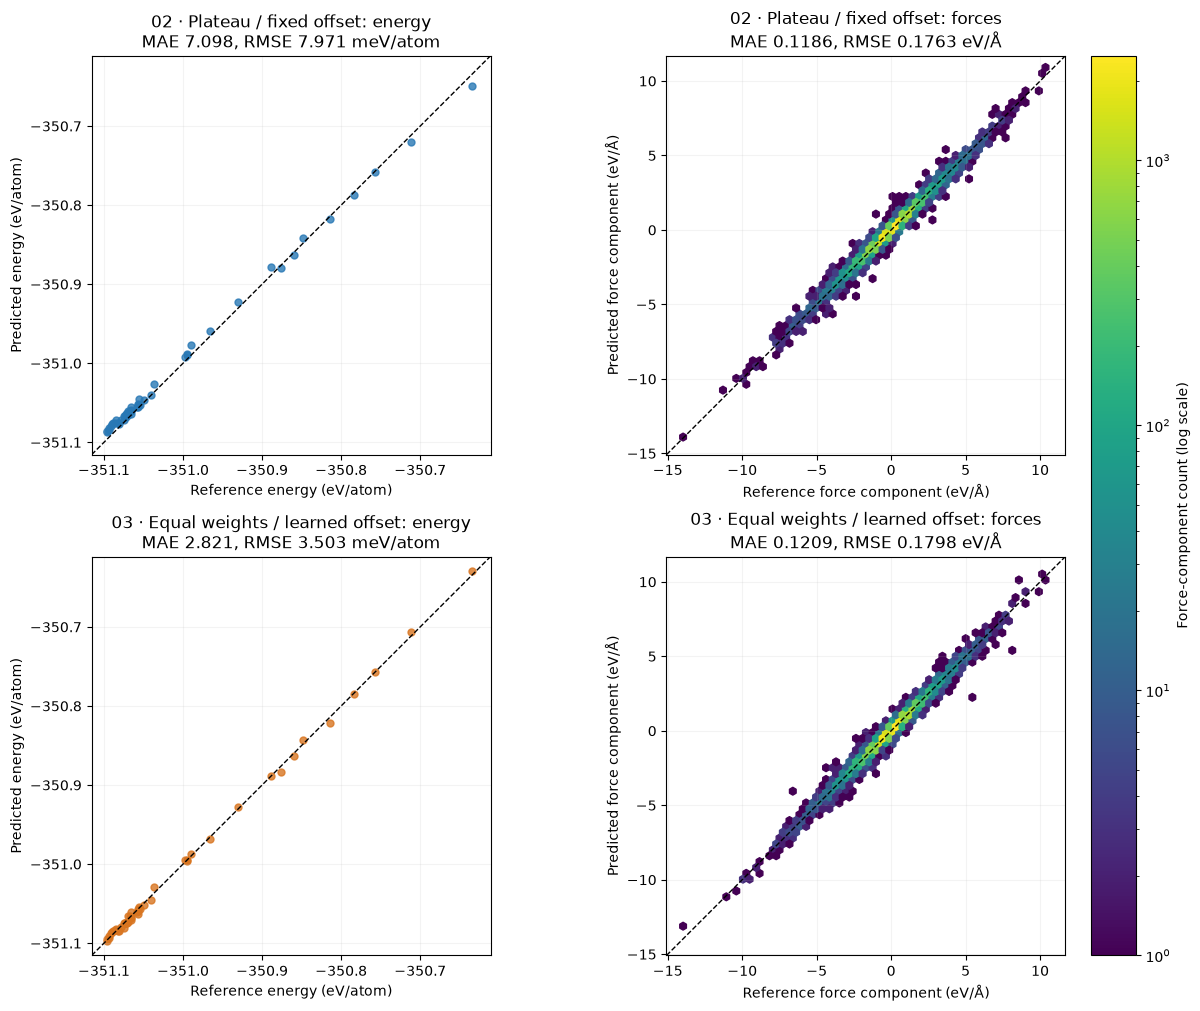

In [7]:
from matplotlib.colors import LogNorm

colours = {"02 · Plateau / fixed offset": "#2878B5", "03 · Equal weights / learned offset": "#D87520"}

def padded_limits(arrays):
    low = min(float(np.min(a)) for a in arrays)
    high = max(float(np.max(a)) for a in arrays)
    margin = 0.04 * (high - low) if high > low else 0.01
    return low - margin, high + margin

ref_epa = reference_energy / n_atoms
energy_limits = padded_limits([ref_epa] + [r["energy"] / n_atoms for r in results.values()])
force_limits = padded_limits([reference_forces] + [r["forces"] for r in results.values()])
force_norm = LogNorm(vmin=1, vmax=max(2, reference_forces.size))

fig_parity, axes = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
hexplots = []
for row, (label, result) in enumerate(results.items()):
    ax = axes[row, 0]
    ax.scatter(ref_epa, result["energy"] / n_atoms, s=25, alpha=0.8, color=colours[label])
    em = metrics.loc[(label, "Energy per atom")]
    ax.set_title(f"{label}: energy\nMAE {em['MAE']:.3f}, RMSE {em['RMSE']:.3f} meV/atom")
    ax.set_xlabel("Reference energy (eV/atom)")
    ax.set_ylabel("Predicted energy (eV/atom)")
    ax.ticklabel_format(useOffset=False, style="plain")

    ax = axes[row, 1]
    hexplots.append(ax.hexbin(
        reference_forces.ravel(), result["forces"].ravel(),
        gridsize=60, extent=(*force_limits, *force_limits),
        mincnt=1, norm=force_norm, cmap="viridis",
    ))
    fm = metrics.loc[(label, "Force components")]
    ax.set_title(f"{label}: forces\nMAE {fm['MAE']:.4f}, RMSE {fm['RMSE']:.4f} eV/Å")
    ax.set_xlabel("Reference force component (eV/Å)")
    ax.set_ylabel("Predicted force component (eV/Å)")

    for col, limits in enumerate([energy_limits, force_limits]):
        ax = axes[row, col]
        ax.plot(limits, limits, "k--", lw=1)
        ax.set(xlim=limits, ylim=limits)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.15)

# Use the largest observed bin count for a shared, readable colour range.
force_norm.vmax = max(2, *(float(h.get_array().max()) for h in hexplots))
fig_parity.colorbar(hexplots[0], ax=list(axes[:, 1]), label="Force-component count (log scale)")
plt.show()

## 6. Compare errors directly

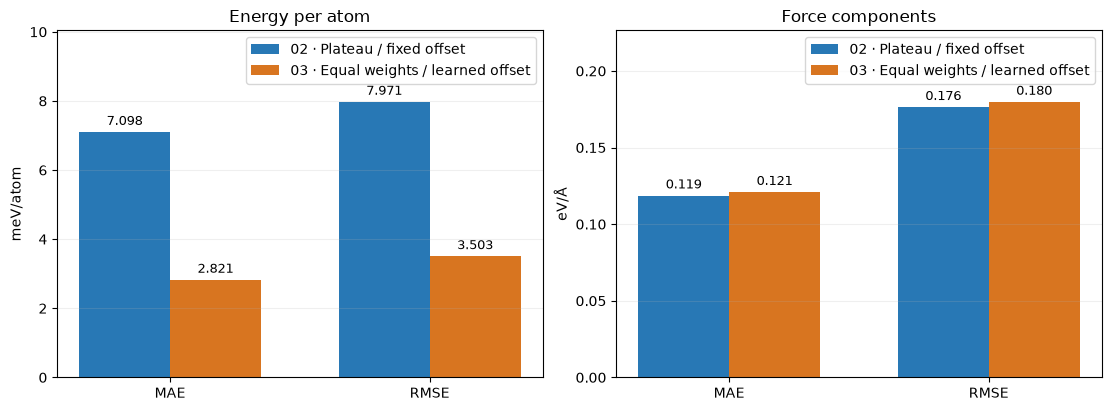

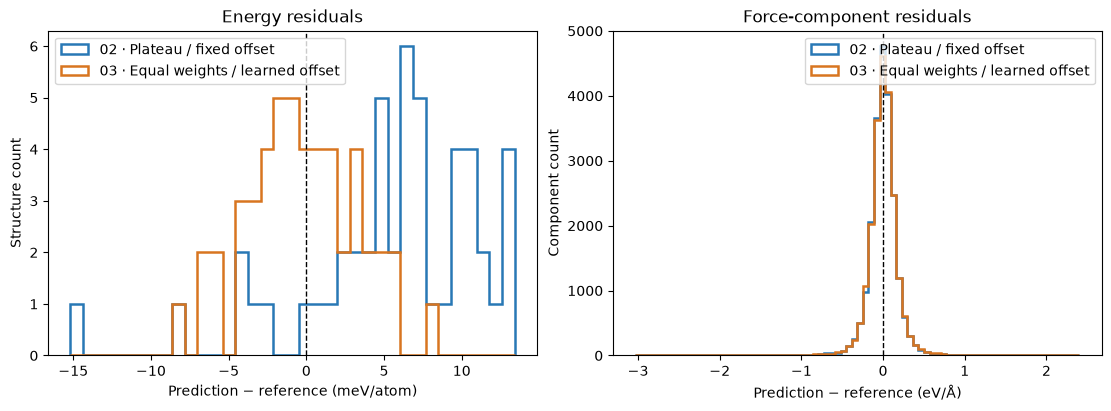

In [8]:
fig_metrics, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
x = np.arange(2)
width = 0.35
for ax, quantity, units in zip(axes, ["Energy per atom", "Force components"], ["meV/atom", "eV/Å"]):
    for j, label in enumerate(labels):
        values = [metrics.loc[(label, quantity), m] for m in ["MAE", "RMSE"]]
        bars = ax.bar(x + (j - 0.5) * width, values, width, label=label, color=colours[label])
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_xticks(x, ["MAE", "RMSE"])
    ax.set_title(quantity)
    ax.set_ylabel(units)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
plt.show()

fig_errors, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, key, units, title in [
    (axes[0], "energy_errors_meV_per_atom", "meV/atom", "Energy residuals"),
    (axes[1], "force_errors", "eV/Å", "Force-component residuals"),
]:
    combined = np.concatenate([r[key].ravel() for r in results.values()])
    bins = np.histogram_bin_edges(combined, bins=35 if ax is axes[0] else 80)
    for label, result in results.items():
        ax.hist(result[key].ravel(), bins=bins, histtype="step", linewidth=1.8,
                color=colours[label], label=label)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(f"Prediction − reference ({units})")
    ax.set_ylabel("Structure count" if ax is axes[0] else "Component count")
    ax.legend()
plt.show()

## 7. Save predictions, metrics and comparison figures

In [9]:
def sha256(path):
    with open(path, "rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()

for label, run in RUNS.items():
    destination = run / "evaluation/validation_03_comparison"
    destination.mkdir(parents=True, exist_ok=True)
    result = results[label]
    result["structures"].to_csv(destination / "predictions.csv", index=False)
    metrics.loc[label].to_csv(destination / "metrics.csv")
    np.savez_compressed(
        destination / "forces.npz",
        n_atoms=n_atoms, atom_offsets=atom_offsets,
        reference=reference_forces, predicted=result["forces"],
    )

metrics.to_csv(OUTPUT / "validation_metrics.csv")
comparison.to_csv(OUTPUT / "validation_comparison.csv")
difference.to_csv(OUTPUT / "03_minus_02.csv")
for name, figure in [("parity", fig_parity), ("metrics", fig_metrics), ("residuals", fig_errors)]:
    figure.savefig(OUTPUT / f"{name}.png", dpi=200, bbox_inches="tight")
    figure.savefig(OUTPUT / f"{name}.pdf", bbox_inches="tight")

manifest = {
    "split": "validation",
    "data_path": str(VALID_PATH.relative_to(PROJECT)),
    "data_sha256": sha256(VALID_PATH),
    "n_structures": len(validation),
    "device": "cpu",
    "graph_pes_version": version("graph-pes"),
    "torch_version": torch.__version__,
    "energy_units": "eV; per-atom metrics displayed in meV/atom",
    "force_units": "eV/Å",
    "runs": {
        label: {"run": run.name, "model_sha256": sha256(run / "model.pt"),
                "config_sha256": sha256(run / "train-config.yaml"),
                "evaluation_seconds": results[label]["evaluation_seconds"]}
        for label, run in RUNS.items()
    },
}
(OUTPUT / "evaluation_manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved comparison:", OUTPUT)

Saved comparison: /Users/louismcauliffe/code/research/SchNET/comparisons/03-6thOctMeeting-adjustments


## 8. Check for overfitting within each run

Training and validation total-loss curves use each run's own loss weights. Inspect their trends within a run; their absolute values are not comparable across runs. Training curves average logged batches, rather than evaluating the full training set. Histories are read from W&B and cached for offline reuse.


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Standalone: this cell also runs without repeating the model evaluations above.
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'data/valid.xyz').is_file())
history_dir = project_root / 'comparisons/03-6thOctMeeting-adjustments/loss-history'
history_dir.mkdir(parents=True, exist_ok=True)
history_runs = {
    '02 · Plateau / fixed offset (1:5)': 'lr-plateau-9002262',
    '03 · Equal weights / learned offset (1:1)': 'lossratio_and_learnedOffsets-9004704',
}
REFRESH_HISTORY = False  # Cached histories let subsequent runs work offline.
loss_histories = {}
api = None
for label, run_id in history_runs.items():
    cache = history_dir / f'{run_id}.csv'
    old_cache = project_root / 'comparisons/02-learning-rate/loss-history' / f'{run_id}.csv'
    if not cache.exists() and old_cache.exists() and not REFRESH_HISTORY:
        cache.write_bytes(old_cache.read_bytes())
    if cache.exists() and not REFRESH_HISTORY:
        history = pd.read_csv(cache)
    else:
        import wandb
        if api is None:
            # Authenticate once with .venv/bin/wandb login in your local terminal.
            # This only reads existing runs; it does not start a new W&B run.
            api = wandb.Api(timeout=60)
        run = api.run(f'trin4011-university-of-oxford/transfer-learning/{run_id}')
        records = []
        # scan_history retrieves the full history, unlike the sampled history API.
        # Fetch separately: training and validation can occupy different rows.
        for split in ['train', 'valid']:
            key = f'{split}/loss/total'
            for row in run.scan_history(keys=['epoch', key], page_size=1000):
                if row.get(key) is not None and row.get('epoch') is not None:
                    records.append({'epoch': row['epoch'], 'split': split,
                                    'loss': row[key]})
        history = pd.DataFrame(records, columns=['epoch', 'split', 'loss'])
        if history.empty or set(history['split']) != {'train', 'valid'}:
            raise ValueError(f'Missing training or validation history for {run_id}.')
        history.to_csv(cache, index=False)
    history['epoch'] = pd.to_numeric(history['epoch'])
    history['loss'] = pd.to_numeric(history['loss'])
    assert np.isfinite(history[['epoch', 'loss']].to_numpy()).all()
    loss_histories[label] = history
    print(f'{label}: {len(history):,} logged loss values')


02 · Plateau / fixed offset (1:5): 6,300 logged loss values


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/louismcauliffe/.netrc.


03 · Equal weights / learned offset (1:1): 6,300 logged loss values


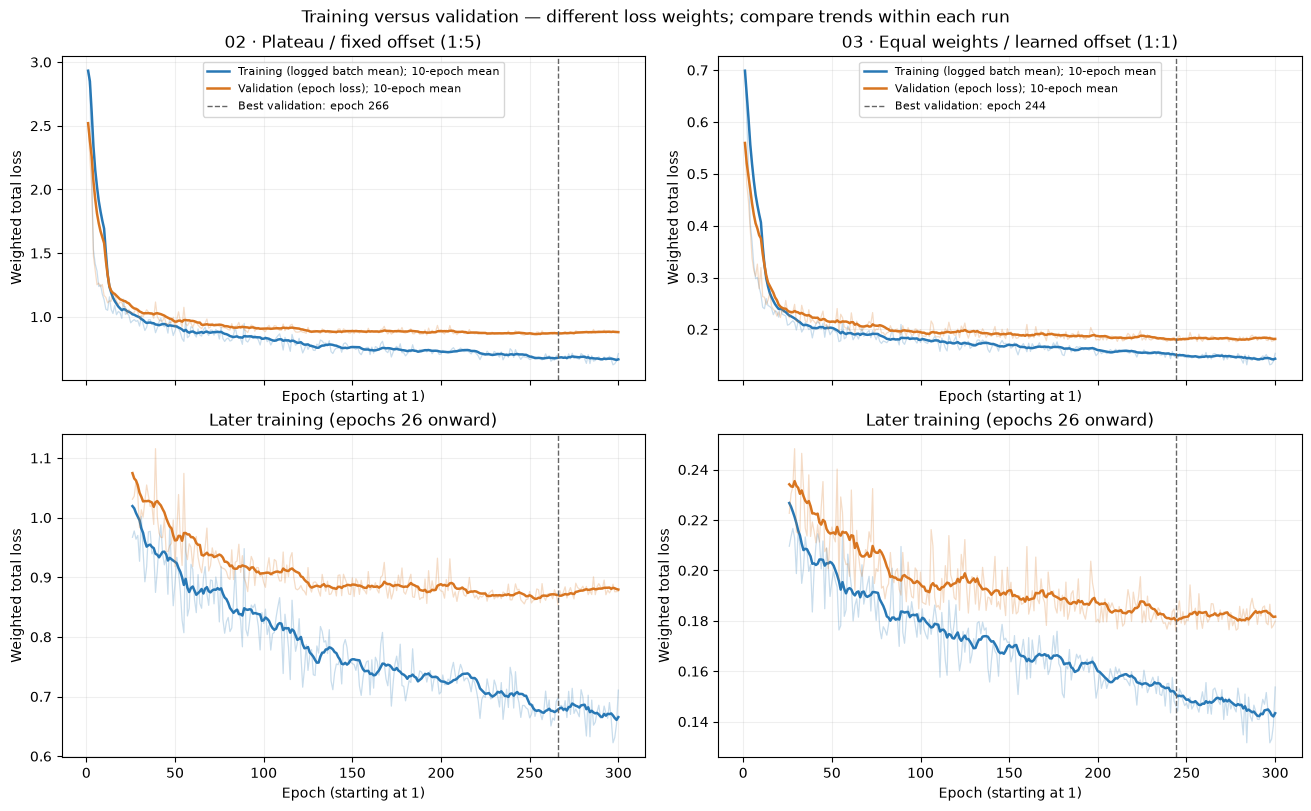

,Best epoch,Best validation loss,Training: previous 25 epochs,Training: final 25 epochs,Training: change,Validation: previous 25 epochs,Validation: final 25 epochs,Validation: change
Run,,,,,,,,
02 · Plateau / fixed offset (1:5),266,0.85428,0.67985,0.66994,-0.00991,0.87059,0.88092,0.01033
03 · Equal weights / learned offset (1:1),244,0.17599,0.14772,0.14382,-0.00390,0.18276,0.18180,-0.00095


Negative change means loss decreased in the final 25-epoch window.
A persistent training decrease with validation increase supports overfitting; a gap alone does not.


In [11]:
fig_losses, axes = plt.subplots(2, 2, figsize=(13, 8), sharex='col', layout='constrained')
loss_trend_rows = []
epoch_histories = {}
for column, (label, history) in enumerate(loss_histories.items()):
    train_rows = history[history['split'].eq('train')]
    valid_rows = history[history['split'].eq('valid')]
    # Mean of LOGGED batches, not an exact full-training-set evaluation.
    train_curve = train_rows.groupby('epoch')['loss'].mean().sort_index()
    valid_curve = valid_rows.groupby('epoch')['loss'].last().sort_index()
    best_epoch = valid_curve.idxmin()
    epoch_histories[label] = (train_curve, valid_curve)
    for row, ax in enumerate(axes[:, column]):
        for curve, name, colour in [(train_curve, 'Training (logged batch mean)', '#2878B5'),
                                    (valid_curve, 'Validation (epoch loss)', '#D87520')]:
            visible = curve if row == 0 else curve[curve.index >= 25]
            ax.plot(visible.index + 1, visible, color=colour, alpha=0.25, linewidth=0.9)
            smooth = curve.rolling(10, min_periods=1).mean()
            smooth = smooth if row == 0 else smooth[smooth.index >= 25]
            ax.plot(smooth.index + 1, smooth, color=colour, linewidth=1.8,
                    label=f'{name}; 10-epoch mean')
        ax.axvline(best_epoch + 1, color='#666666', linestyle='--', linewidth=1,
                   label=f'Best validation: epoch {int(best_epoch) + 1}')
        ax.grid(alpha=0.2)
        ax.set_xlabel('Epoch (starting at 1)')
        ax.set_ylabel('Weighted total loss')
        ax.set_title(label if row == 0 else 'Later training (epochs 26 onward)')
        if row == 0:
            ax.legend(fontsize=8)
    # Descriptive comparison of adjacent windows, not a statistical test.
    end = int(valid_curve.index.max())
    row = {'Run': label, 'Best epoch': int(best_epoch) + 1,
           'Best validation loss': valid_curve.min()}
    for name, curve in [('Training', train_curve), ('Validation', valid_curve)]:
        previous = curve[(curve.index > end - 50) & (curve.index <= end - 25)].mean()
        final = curve[(curve.index > end - 25) & (curve.index <= end)].mean()
        row[f'{name}: previous 25 epochs'] = previous
        row[f'{name}: final 25 epochs'] = final
        row[f'{name}: change'] = final - previous
    loss_trend_rows.append(row)

# Independent y scales: loss definitions differ between runs.
fig_losses.suptitle('Training versus validation — different loss weights; compare trends within each run')
plt.show()
loss_trends = pd.DataFrame(loss_trend_rows).set_index('Run')
display(loss_trends.round(5))
loss_trends.to_csv(history_dir / 'late_training_trends.csv')
for extension in ['png', 'pdf']:
    fig_losses.savefig(history_dir / f'training_vs_validation.{extension}', dpi=180)
print('Negative change means loss decreased in the final 25-epoch window.')
print('A persistent training decrease with validation increase supports overfitting; a gap alone does not.')
